In [1]:
# ============================================================
# F4 — Week 05 Black-Box Optimisation
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# ============================================================

# =========================
# Imports (top of notebook)
# =========================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from scipy.stats.qmc import Sobol

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# =========================
# 0) CONFIG (F4) — Week 05
# =========================
FN = "F4"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ----- Paths (course repo structure) -----
INPUTS_PATH = "data/F4/initial_inputs.npy"
OUTPUTS_PATH = "data/F4/initial_outputs.npy"

# Fallback paths (for Colab / sandbox testing)
FALLBACK_INPUTS = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS = "/mnt/data/initial_outputs.npy"

# ----- Problem bounds (scaled) -----
BOUNDS = np.array([
    [0.0, 1.0],  # x1
    [0.0, 1.0],  # x2
    [0.0, 1.0],  # x3
    [0.0, 1.0],  # x4
], dtype=float)

# ----- Surrogate / BO parameters -----
# Ensemble uncertainty proxy (epistemic-ish): std across models
N_ENSEMBLE = 24
N_CAND = 8192  # Sobol candidates

# Week 05: slightly more exploitative than Week 04 (2.2 → 1.6)
KAPPA = 1.6

# Diversity penalty discourages resampling near existing points
DIVERSITY_LAMBDA = 0.10
R_DIVERSITY = 0.10

# Guardrail: if best candidate is too close, fall back to next best
MIN_DIST_FLOOR = 1e-3

TOPK = 10  # show a few backups


In [3]:
# =========================
# 1) LOAD DATA
# =========================
in_path = INPUTS_PATH if os.path.exists(INPUTS_PATH) else FALLBACK_INPUTS
out_path = OUTPUTS_PATH if os.path.exists(OUTPUTS_PATH) else FALLBACK_OUTPUTS

X = np.load(in_path)
y = np.load(out_path).ravel()

assert X.ndim == 2 and X.shape[1] == 4, "Expected X shape (n, 4) for F4."
assert X.shape[0] == y.shape[0], "X and y must have the same number of rows."

print(f"{FN} data loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("y min / max:", float(y.min()), float(y.max()))
print("Last evaluated point:", np.round(X[-1], 6), "→ y =", float(y[-1]))

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"])
df["y"] = y

F4 data loaded
X shape: (34, 4)
y shape: (34,)
y min / max: -46.39338781605223 0.5802719111663213
Last evaluated point: [0.39805  0.434198 0.4073   0.316278] → y = -0.4211763480512043


In [4]:
# =========================
# 2) SURROGATE (ENSEMBLE EXTRA TREES) + UNCERTAINTY
# =========================
def make_model(seed: int) -> ExtraTreesRegressor:
    return ExtraTreesRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=seed,
        n_jobs=-1
    )

models = []
for s in range(N_ENSEMBLE):
    m = make_model(RANDOM_SEED + s)
    m.fit(X, y)
    models.append(m)

def ensemble_predict(models, Xp: np.ndarray):
    preds = np.column_stack([m.predict(Xp) for m in models])
    mu = preds.mean(axis=1)
    sigma = preds.std(axis=1)
    sigma = np.maximum(sigma, 1e-9)  # numeric floor
    return mu, sigma, preds

# In-sample (for quick diagnostics)
mu_train, sigma_train, _ = ensemble_predict(models, X)

# Feature importances (average across ensemble)
feat_imp = np.mean([m.feature_importances_ for m in models], axis=0)
feat_names = ["x1", "x2", "x3", "x4"]

In [5]:
# =========================
# 3) ACQUISITION (UCB + DIVERSITY PENALTY) → pick NEXT x
# =========================
d = X.shape[1]
sampler = Sobol(d=d, scramble=True, seed=RANDOM_SEED)
m_pow = int(np.ceil(np.log2(N_CAND)))
Xcand = sampler.random_base2(m=m_pow)[:N_CAND]

# Clip to bounds (just in case)
for j in range(d):
    Xcand[:, j] = np.clip(Xcand[:, j], BOUNDS[j, 0], BOUNDS[j, 1])

mu_c, sigma_c, _ = ensemble_predict(models, Xcand)

# UCB (maximize)
ucb = mu_c + KAPPA * sigma_c

# Diversity penalty via distance to nearest observed point
d2 = ((Xcand[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)
min_d2 = d2.min(axis=1)
min_dist = np.sqrt(min_d2)

penalty = DIVERSITY_LAMBDA * np.exp(-min_d2 / (2.0 * (R_DIVERSITY ** 2)))
score = ucb - penalty

# Choose best, but avoid duplicates / ultra-close proposals
rank = np.argsort(score)[::-1]
chosen_idx = None
for idx in rank:
    if min_dist[idx] > MIN_DIST_FLOOR:
        chosen_idx = int(idx)
        break
if chosen_idx is None:
    chosen_idx = int(rank[0])  # last resort

x_next = Xcand[chosen_idx].copy()


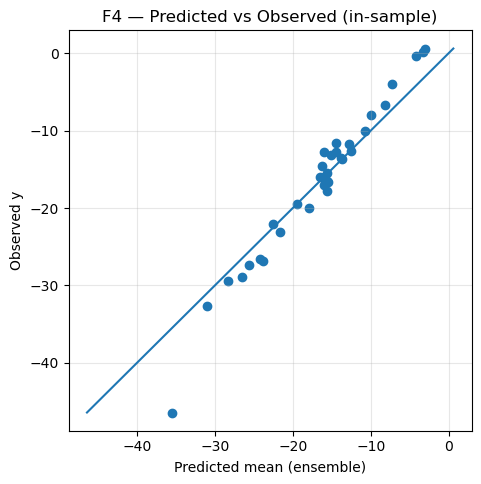

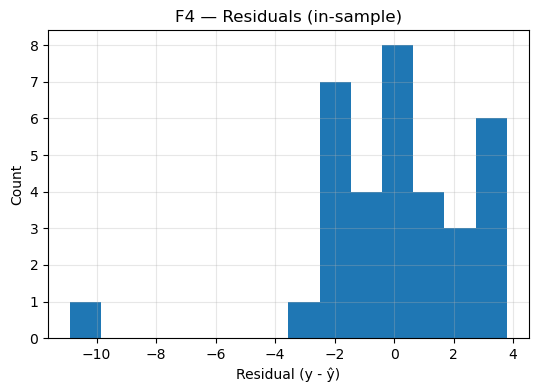

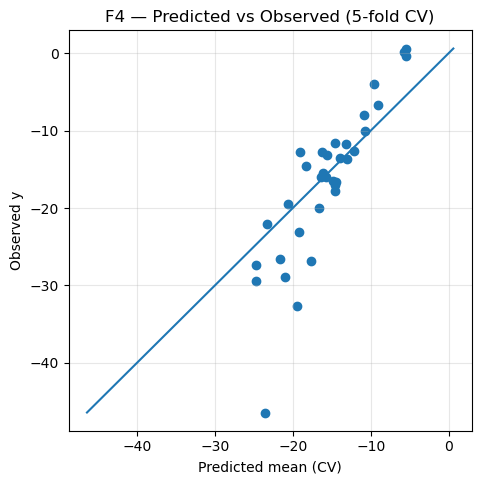

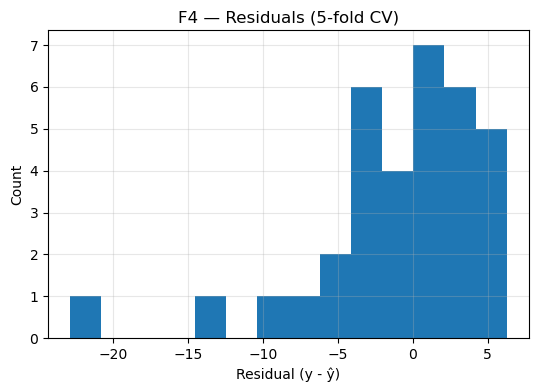

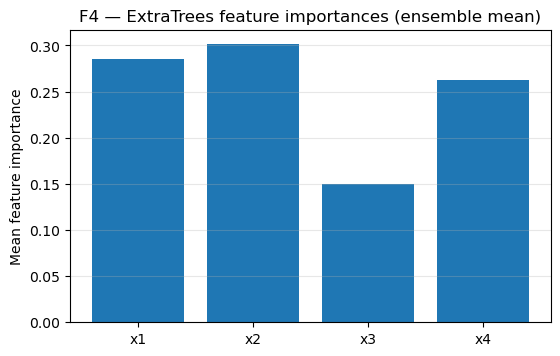

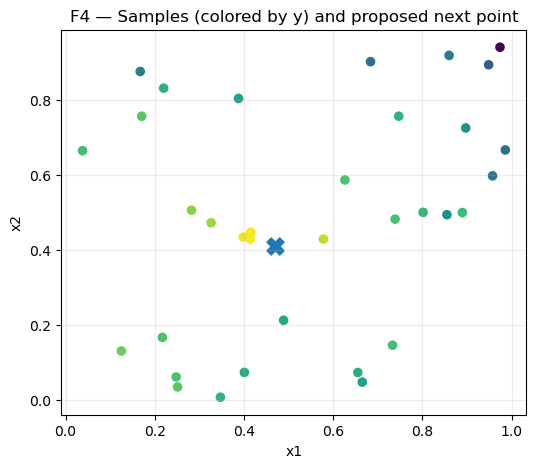

Chosen point min distance to existing samples: 0.06920359861583154


In [6]:
# =========================
# 4) DIAGNOSTICS
# =========================
# 4.1 Predicted vs observed (in-sample, quick sanity)
plt.figure(figsize=(5.2, 5.2))
plt.scatter(mu_train, y)
lo = float(min(mu_train.min(), y.min()))
hi = float(max(mu_train.max(), y.max()))
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Predicted mean (ensemble)")
plt.ylabel("Observed y")
plt.title("F4 — Predicted vs Observed (in-sample)")
plt.grid(True, alpha=0.3)
plt.show()

# 4.2 Residuals histogram (in-sample)
resid = y - mu_train
plt.figure(figsize=(6.2, 4.0))
plt.hist(resid, bins=14)
plt.xlabel("Residual (y - ŷ)")
plt.ylabel("Count")
plt.title("F4 — Residuals (in-sample)")
plt.grid(True, alpha=0.3)
plt.show()

# 4.3 Simple CV check (5-fold): helps detect overfit / bias
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
mu_cv = np.zeros_like(y, dtype=float)

for tr, te in kf.split(X):
    fold_models = []
    for s in range(max(8, N_ENSEMBLE // 3)):  # lighter ensemble per fold
        fm = make_model(RANDOM_SEED + 1000 + s)
        fm.fit(X[tr], y[tr])
        fold_models.append(fm)
    mu_fold, _, _ = ensemble_predict(fold_models, X[te])
    mu_cv[te] = mu_fold

cv_resid = y - mu_cv
plt.figure(figsize=(5.2, 5.2))
plt.scatter(mu_cv, y)
lo = float(min(mu_cv.min(), y.min()))
hi = float(max(mu_cv.max(), y.max()))
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Predicted mean (CV)")
plt.ylabel("Observed y")
plt.title("F4 — Predicted vs Observed (5-fold CV)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6.2, 4.0))
plt.hist(cv_resid, bins=14)
plt.xlabel("Residual (y - ŷ)")
plt.ylabel("Count")
plt.title("F4 — Residuals (5-fold CV)")
plt.grid(True, alpha=0.3)
plt.show()

# 4.4 Feature importances
plt.figure(figsize=(6.2, 3.8))
plt.bar(feat_names, feat_imp)
plt.ylabel("Mean feature importance")
plt.title("F4 — ExtraTrees feature importances (ensemble mean)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# 4.5 “Not stuck” check: where are we sampling? (x1 vs x2 view)
plt.figure(figsize=(6.0, 5.0))
plt.scatter(X[:, 0], X[:, 1], c=y, s=35)
plt.scatter([x_next[0]], [x_next[1]], marker="X", s=150)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("F4 — Samples (colored by y) and proposed next point")
plt.grid(True, alpha=0.25)
plt.show()

# 4.6 Distance-to-data check for chosen point
print("Chosen point min distance to existing samples:", float(min_dist[chosen_idx]))



In [7]:
# =========================
# 5) OUTPUT (ONE ROW TO SUBMIT)
# =========================
print("\n=== RECOMMENDED NEXT X (submit ONE row) ===")
print(x_next)
print("Rounded (6 dp):", np.round(x_next, 6))

# Backup candidates (top-scoring distinct-ish points)
top_idx = rank[:TOPK]
backup = np.round(Xcand[top_idx], 6)
backup_dist = np.round(min_dist[top_idx], 6)

print("\nTop backup candidates (rounded) + min_dist:")
for i in range(len(top_idx)):
    print(f"{i+1:02d}:", backup[i], "  min_dist=", float(backup_dist[i]))


=== RECOMMENDED NEXT X (submit ONE row) ===
[0.46946352 0.40984098 0.36545397 0.38934667]
Rounded (6 dp): [0.469464 0.409841 0.365454 0.389347]

Top backup candidates (rounded) + min_dist:
01: [0.415091 0.447439 0.379873 0.420895]   min_dist= 0.0
02: [0.39805  0.434198 0.4073   0.316278]   min_dist= 1e-06
03: [0.469464 0.409841 0.365454 0.389347]   min_dist= 0.069204
04: [0.350888 0.440084 0.404003 0.281112]   min_dist= 0.059215
05: [0.466965 0.458123 0.331877 0.347234]   min_dist= 0.102638
06: [0.424395 0.399481 0.400456 0.170101]   min_dist= 0.147931
07: [0.449829 0.33783  0.425977 0.362866]   min_dist= 0.117373
08: [0.295874 0.417135 0.358849 0.312089]   min_dist= 0.114438
09: [0.357418 0.486615 0.441965 0.393388]   min_dist= 0.097329
10: [0.433344 0.319104 0.346777 0.436513]   min_dist= 0.120788
